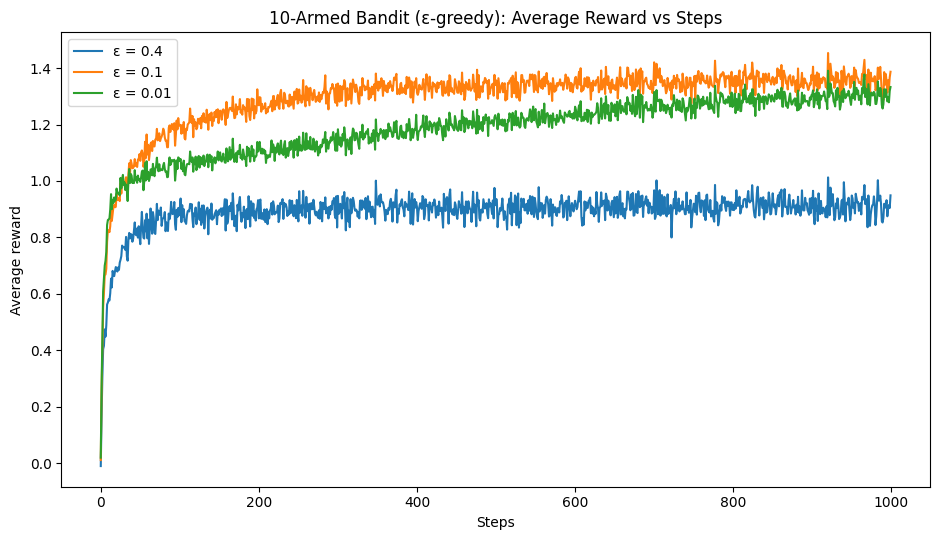

Saved figure: bandit_epsilon_comparison.png

Impact of ε (exploration rate):

• ε = 0.4 explores *a lot*. It learns fast at the start, but it keeps making random moves forever,
  so it never really settles in. That’s why the long-run reward ends up the lowest on our plot.

• ε = 0.1 is the sweet spot here. It explores enough early to find good arms, but still exploits most
  of the time, so it levels out at the highest average reward in our results.

• ε = 0.01 barely explores. It starts off decent, but it improves slower because it doesn’t “try new stuff”
  very often. In our plot it keeps creeping up, but it stays below ε = 0.1 by the end.

Overall: bigger ε = better early exploration but worse long-run reward; smaller ε = stronger exploitation
but it can take longer to reliably find the best arm.



In [ ]:
# Noah Russell 

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 10-armed bandit testbed (matches our lecture setup)
# - True action values:   q*(a) ~ N(0, 1)
# - Rewards:              Rt ~ N(q*(a), 1)
# - Run for 1000 steps and repeat across 2000 different bandits
# ------------------------------------------------------------

def run_testbed(epsilon, k=10, steps=1000, runs=2000, seed=7):
    rng = np.random.default_rng(seed)

    # Make a new "world" for each run: each run has its own 10 true arm values
    q_true = rng.normal(0.0, 1.0, size=(runs, k))
    optimal_action = np.argmax(q_true, axis=1)  # best arm for each run (just for tracking)

    # What the agent believes (Q estimates) + how many times it tried each arm
    q_est = np.zeros((runs, k), dtype=np.float64)
    n = np.zeros((runs, k), dtype=np.int64)

    avg_reward = np.zeros(steps, dtype=np.float64)
    pct_optimal = np.zeros(steps, dtype=np.float64)

    run_idx = np.arange(runs)

    for t in range(steps):
        # ε-greedy: with prob ε we explore; otherwise we pick the current best-known arm
        explore = rng.random(runs) < epsilon

        # Greedy pick (tie-break by adding a tiny bit of noise so argmax doesn't always pick the first)
        greedy = np.argmax(q_est + rng.normal(0.0, 1e-8, size=q_est.shape), axis=1)

        # Random arm for exploration
        rand_actions = rng.integers(0, k, size=runs)

        # Final action choice per run
        actions = np.where(explore, rand_actions, greedy)

        # Pull the chosen arm and get reward: Rt ~ N(q*(a), 1)
        means = q_true[run_idx, actions]
        rewards = rng.normal(means, 1.0)

        # Update Q using sample-average:
        # Q <- Q + (1/N) * (R - Q)
        n[run_idx, actions] += 1
        counts = n[run_idx, actions].astype(np.float64)
        old = q_est[run_idx, actions]
        q_est[run_idx, actions] = old + (rewards - old) / counts

        # Track the averages we care about
        avg_reward[t] = rewards.mean()
        pct_optimal[t] = (actions == optimal_action).mean() * 100.0

    return avg_reward, pct_optimal


# ------------------------------------------------------------
# Compare epsilons (what the HW asks for)
# ------------------------------------------------------------
epsilons = [0.4, 0.1, 0.01]
k = 10
steps = 1000   # matches the lecture slide setup
runs = 2000    # matches the lecture slide setup
seed = 7

results = {}
for eps in epsilons:
    avg_reward, pct_opt = run_testbed(eps, k=k, steps=steps, runs=runs, seed=seed)
    results[eps] = (avg_reward, pct_opt)

# ------------------------------------------------------------
# SINGLE FIGURE: Average reward comparison
# ------------------------------------------------------------
plt.figure(figsize=(9.5, 5.5))
for eps in epsilons:
    plt.plot(results[eps][0], label=f"ε = {eps}")

plt.title("10-Armed Bandit (ε-greedy): Average Reward vs Steps")
plt.xlabel("Steps")
plt.ylabel("Average reward")
plt.legend()
plt.tight_layout()

# Save the figure so you can drop it straight into your PDF
plt.savefig("bandit_epsilon_comparison.png", dpi=200)
plt.show()

print("Saved figure: bandit_epsilon_comparison.png")


# ------------------------------------------------------------
# Casual analysis text (matches what YOUR plot actually shows)
# ------------------------------------------------------------
analysis = """
Impact of ε (exploration rate):

• ε = 0.4 explores *a lot*. It learns fast at the start, but it keeps making random moves forever,
  so it never really settles in. That’s why the long-run reward ends up the lowest on our plot.

• ε = 0.1 is the sweet spot here. It explores enough early to find good arms, but still exploits most
  of the time, so it levels out at the highest average reward in our results.

• ε = 0.01 barely explores. It starts off decent, but it improves slower because it doesn’t “try new stuff”
  very often. In our plot it keeps creeping up, but it stays below ε = 0.1 by the end.

Overall: bigger ε = better early exploration but worse long-run reward; smaller ε = stronger exploitation
but it can take longer to reliably find the best arm.
"""
print(analysis)
